 # Project 1: Clinical Prediction of Heart Failure Mortality

- Objective: 
    To develop a predictive model that identifies high risk heart failure patients based on clinical features. It aims to assist 
    in early medical treatment and reduce mortality rates.
- Technical components:
    - Exploratory Analysis: Correlation visualization between clinical factors (e.g., chest pain type) and survival.
    - Preprocessing: Handling numerical and categorical data and implementing StandardScaler for feature normalization.
    - Machine Learning: Comparison of SVM and Artificial Neural Networks (ANN).
    - Evaluation: Measuring succes of the model with Precision, Recall and F1-score to ensure the model is reliable for medical diagnostics.

## Importing Libraries 

In [1]:
# Import Warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Standard Data Manipulation and Visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Machine Learning
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler   # For feature scaling (for SVM and Neural Networks)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report  # Comprehensive metric review
from sklearn import svm

In [4]:
# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout  # Dropout helps prevent overfitting in Neural Networks
from tensorflow.keras import callbacks

## Data Importing and Analysis

In [5]:
# Goal: Identify features that correlates most with HeartDisease
data_df = pd.read_csv("heart.csv")
data_df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [6]:
# Identify categorical columns for later conversion and check for missing values
data_df.info()
# .info() confirms there are no missing values (NaN)

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [7]:
data_df.isnull().sum()
# No missing values are seen here, further investigation is required

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

### Visualizing Target Variables and Find Potential Skewness

[Text(0, 0, '410')]

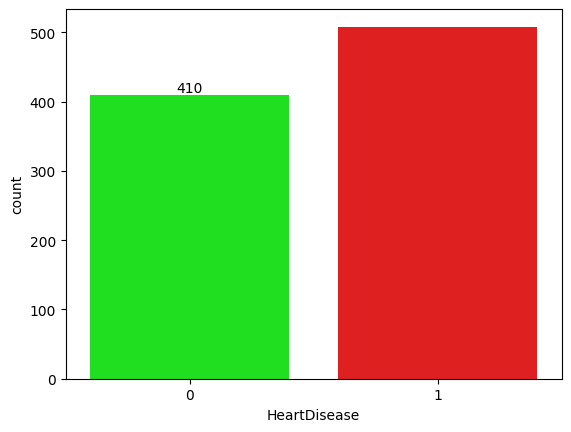

In [8]:
# Visualize class distribution of target variable "HeartDisease"
# Check for class imbalance
cols = ["#00FF00", "#FF0000"]
ax = sns.countplot(x = data_df["HeartDisease"], palette = cols)
ax.bar_label(ax.containers[0])

In [9]:
data_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


Observations:
- RestingBP and Cholesterol show min values of 0. These will be treated as hidden missing values and will be imputed using median to prevent biasing the model.
- Oldpeak is retained (with min value -2.6) as it is a valid clinical marker.
- Cholesterol shows max of 603 which is extreme but possible, so this will be retained.

### Imputing Hidden Missing Values

In [10]:
cols_to_fix = ['RestingBP', 'Cholesterol']
for col in cols_to_fix:
    data_df[col] = data_df[col].replace(0, np.nan)   # Flag 0s as NaN
    data_df[col] = data_df[col].fillna(data_df[col].median())   # Fill with median

In [11]:
for col in cols_to_fix:
    print((data_df[col] == 0).sum())
data_df[cols_to_fix].min()

0
0


RestingBP      80.0
Cholesterol    85.0
dtype: float64

- A non zero min confirms hidden missing values have been successfully imputed

### Evaluating Age Distributions as per Disease Status

<Axes: xlabel='Age', ylabel='count'>

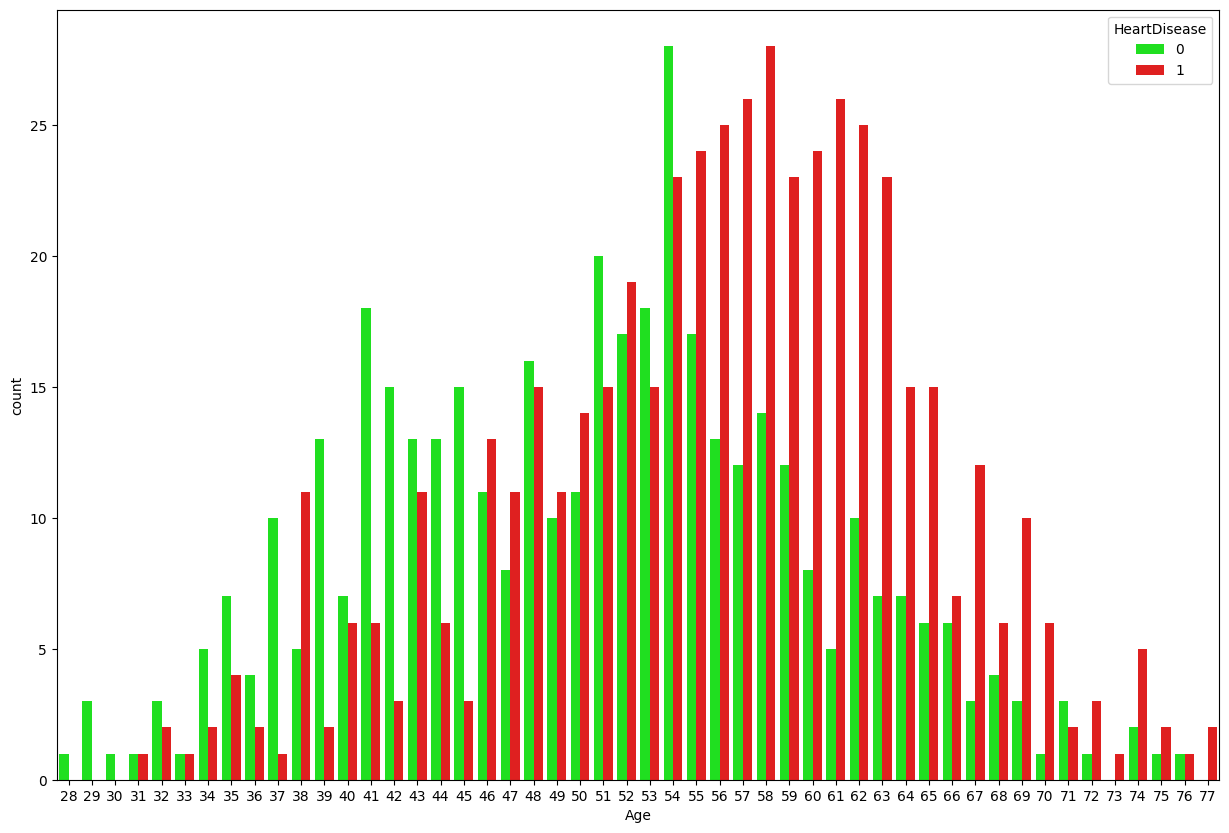

In [12]:
plt.figure(figsize = [15, 10])
sns.countplot(x = data_df['Age'], data = data_df, hue = "HeartDisease", palette = cols)

Observations:
- Up untial age 50 there are more healthy cases, but after this there are more heart disease cases than healthy individuals.
- There is a high density of heart disease cases in the 54-63 age range, showing that age is a high impact feature here. 

### Feature vs. HeartDisease Plot for every Feature

#### Numerical Features

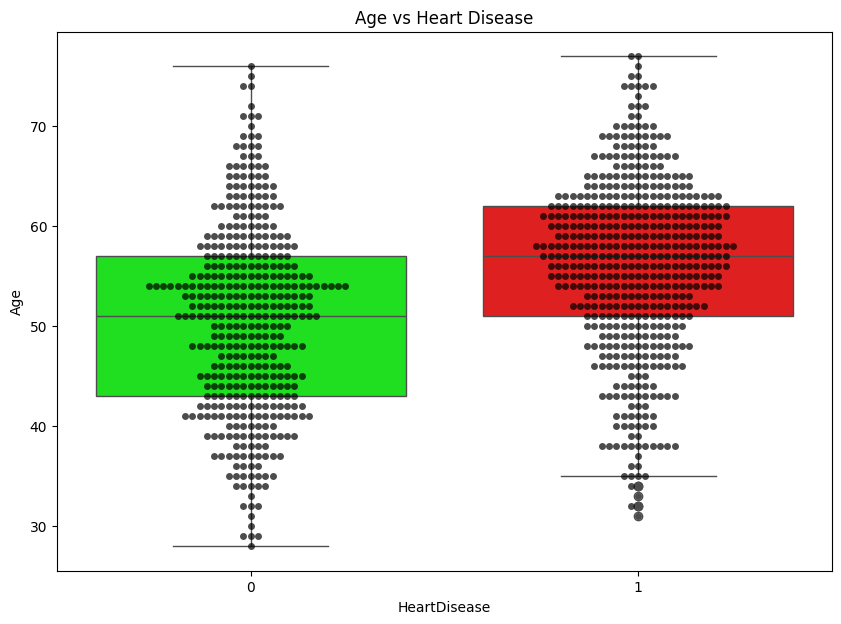

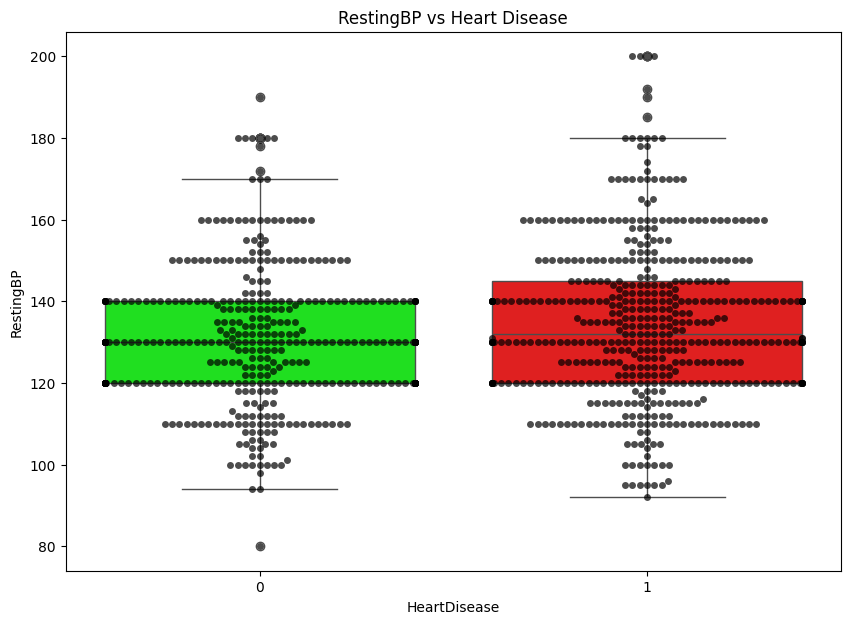

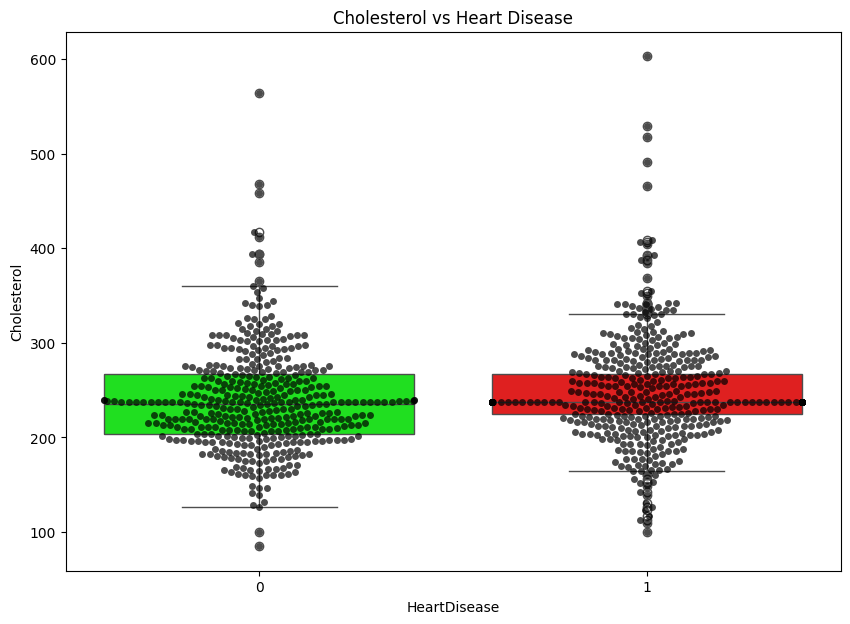

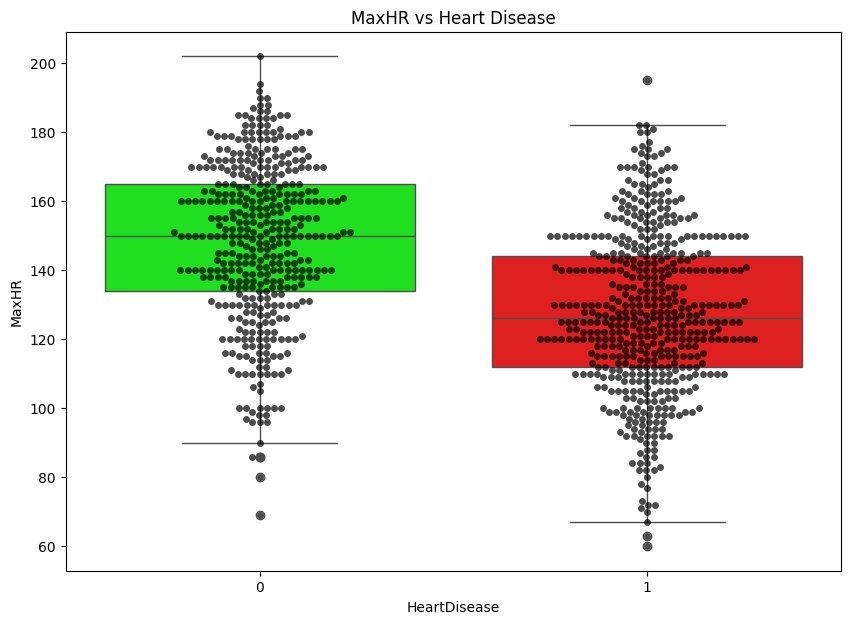

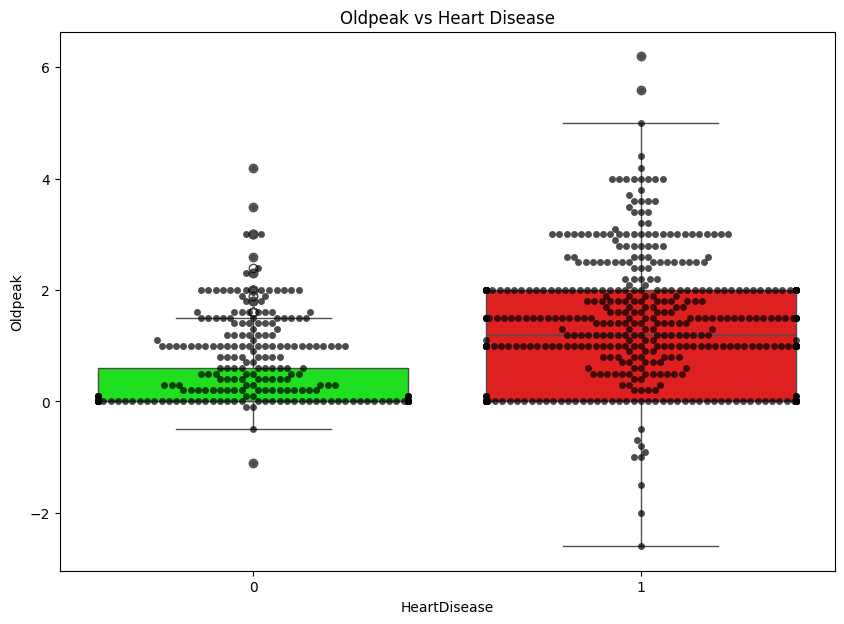

In [13]:
# Plotting Numerical Features
numerical_features = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
for i in numerical_features:
    plt.figure(figsize = [10, 7])
    sns.swarmplot(x = data_df["HeartDisease"], y = data_df[i], color = "black", alpha = 0.7)
    sns.boxplot(x = data_df["HeartDisease"], y = data_df[i], palette = cols)
    plt.title(f'{i} vs Heart Disease')
    plt.show()

Observations:
- Age: The median Age for patients with heart disease (55 - 65) is much higher than for healthy patients.
- RestingBP: RestingBP for healthy patients is 120-140 and for heart disease patients it is slightly more, 120-145.
- Cholesterol: There is an overlap between the two classes which shows that Cholesterol is a contributing factor. The outliers indicate high risk cases.
- MaxHR: Healthy individuals show a much higher median MaxHR compared to those with heart disease, so it is an important feature.
- Oldpeak: High values of Oldpeak (ST depression) are seen majorly in the heart disease group.

#### Categorical Features

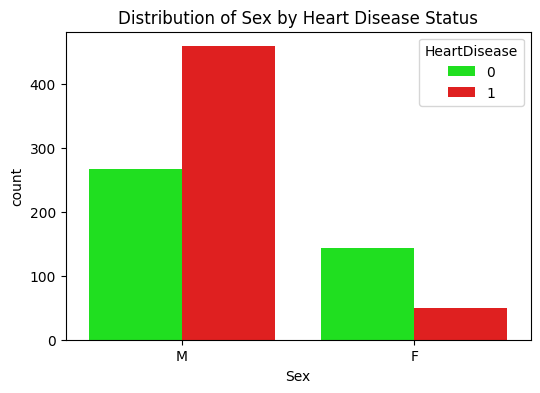

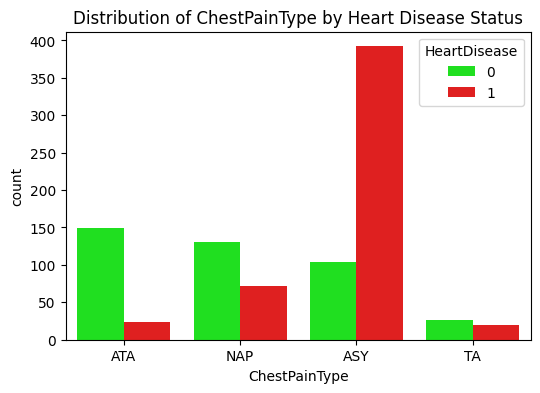

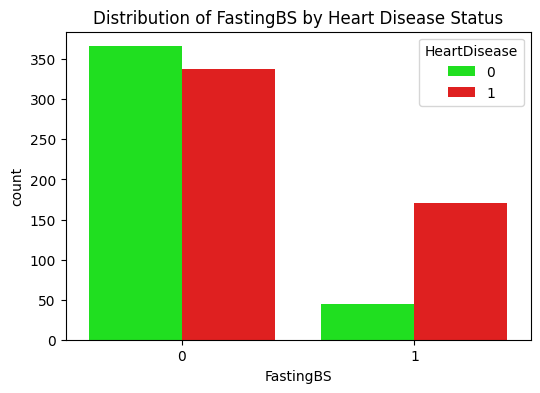

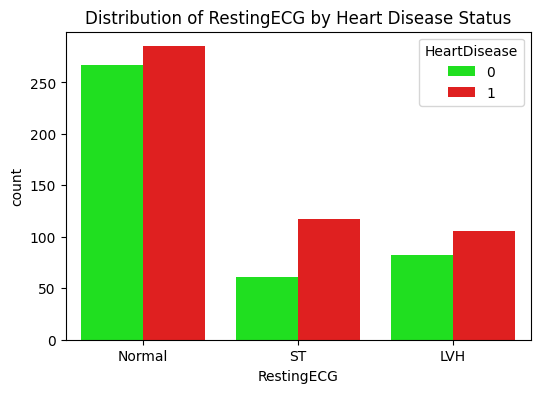

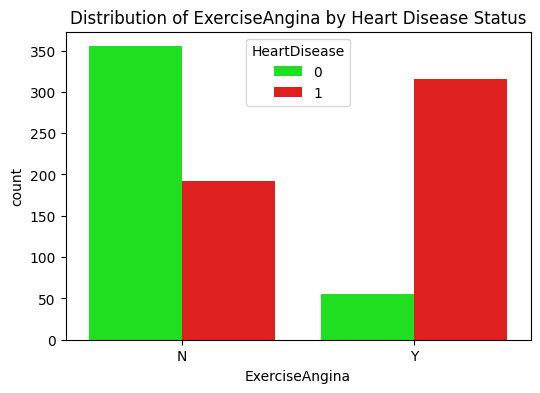

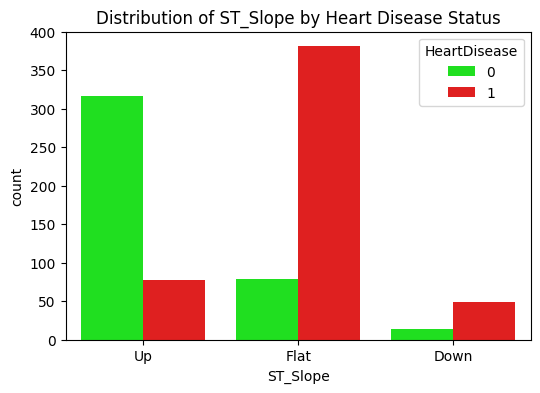

In [14]:
# Plotting Categorical Features
categorical_features = ["Sex", "ChestPainType", "FastingBS", "RestingECG", "ExerciseAngina", "ST_Slope"]
for i in categorical_features:
    plt.figure(figsize = [6, 4])
    sns.countplot(x = data_df[i], hue = data_df["HeartDisease"], palette = cols)
    plt.title(f'Distribution of {i} by Heart Disease Status')
    plt.show()

Observations:
- Sex: Male patients show a much larger proportion of heart disease cases as compared to females in this group.
- ChestPainType: Majority of Asymptomatic (ASY) chest pain cases lead to heart disease.
- FastingBS: While high fasting blood sugar (>120) is less frequent in the datset, it strongly correlates with a heart disease outcome.
- RestingECG: Abnormal ECG results (ST and LVH) show a higher ratio of heart disease. But Normal results also have heart disease, so ECG alone can't conclude heart disease.
- ExerciseAngina: Angina caused by exercise is a highly specific indicator of heart disease in this group.
- ST_Slope: Flat and Down ST slopes are major indicators of heart failure mortality. 

## Data Preprocessing

### Converting Text Columns into Numerical Format

#### Feature Transformation: One-Hot Encoding

In [15]:
# Converting text columns into variables (0s and 1s) as ML models need mathematical inputs
# Ensuring a uniform data structure
data_df = pd.get_dummies(data_df)
data_df = data_df.astype(int)
data_df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
1,49,160,180,0,156,1,1,1,0,0,...,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,0,1,0,...,0,0,0,0,1,1,0,0,0,1
3,48,138,214,0,108,1,1,1,0,1,...,0,0,0,1,0,0,1,0,1,0
4,54,150,195,0,122,0,0,0,1,0,...,1,0,0,1,0,1,0,0,0,1


In [16]:
data_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.0,54.0,60.0,77.0
RestingBP,918.0,132.538126,17.990127,80.0,120.0,130.0,140.0,200.0
Cholesterol,918.0,243.204793,53.401297,85.0,214.0,237.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.0,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.0,138.0,156.0,202.0
Oldpeak,918.0,0.720044,0.990165,-2.0,0.0,0.0,1.0,6.0
HeartDisease,918.0,0.553377,0.497414,0.0,0.0,1.0,1.0,1.0
Sex_F,918.0,0.210240,0.407701,0.0,0.0,0.0,0.0,1.0
Sex_M,918.0,0.789760,0.407701,0.0,1.0,1.0,1.0,1.0
ChestPainType_ASY,918.0,0.540305,0.498645,0.0,0.0,1.0,1.0,1.0


- Features (Sex, ChestPainType, RestingECG, ExerciseAngine, ST_Slope) have been split into different categories 

#### Correlation of all Features

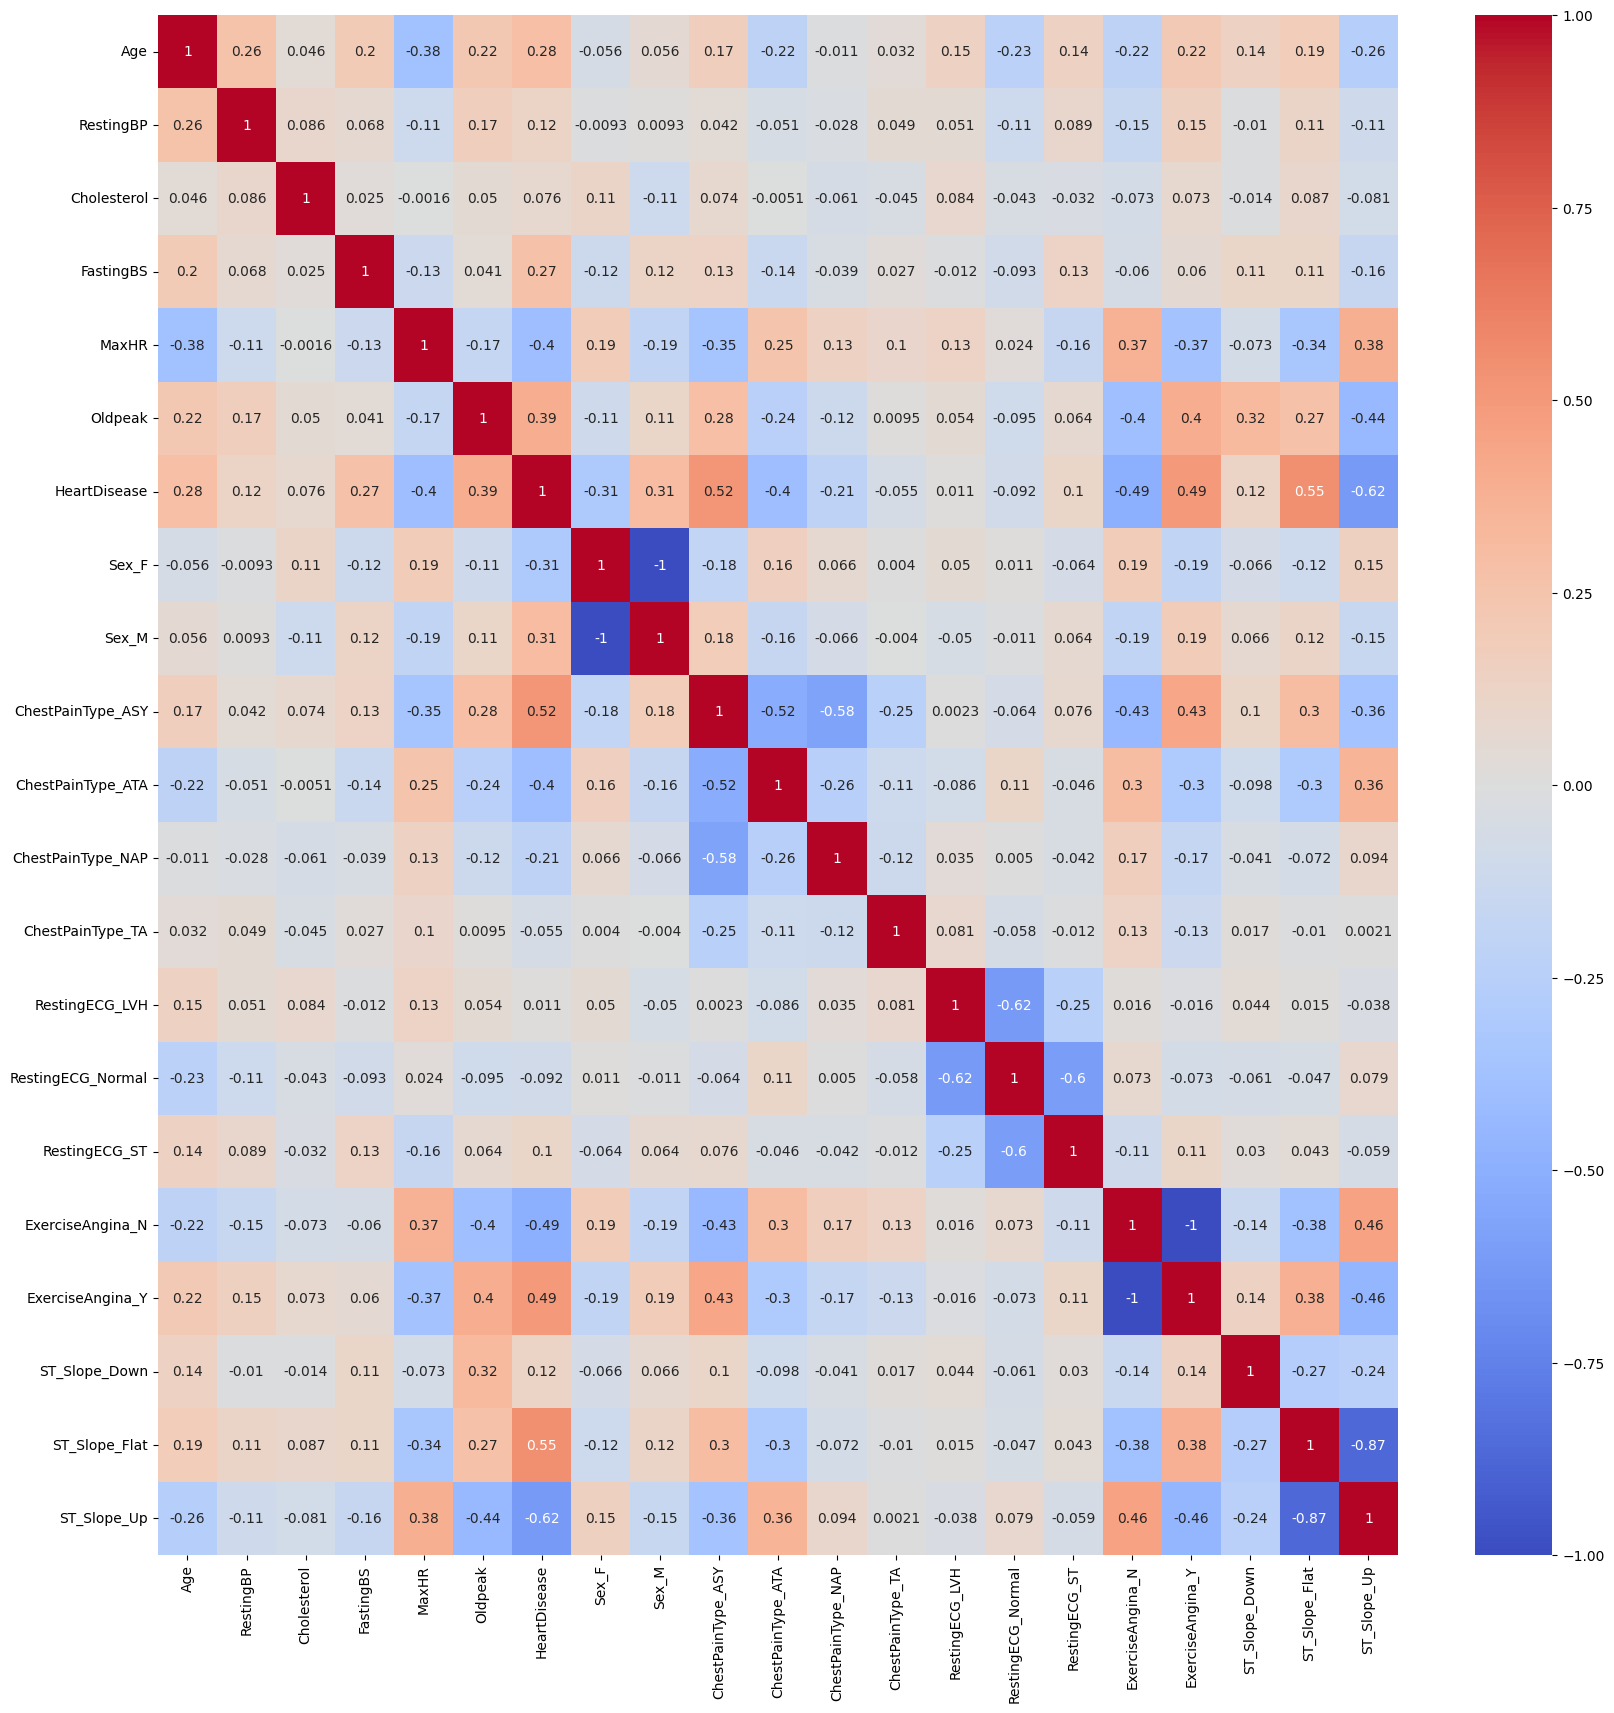

In [17]:
# Visualizing the relationship between all features and target variable 'HeartDisease'
# Identify high impact features 
plt.subplots(figsize = [20, 20])
sns.heatmap(data_df.corr(), cmap = "coolwarm", annot = True)
plt.show()

Observations:
- Strong Positive Predictors:
    - ST_Slope_Flat and ST_Slope_Down: Show a strong positive correlation with HeartDisease.
    - ChestPainType_ASY: This is highly correlated with the target variable.
    - ExerciseAngina: This is higly correlated with HeartDisease.
- Strong Negative Predictors:
    - ST_Slope_Up: This is negatively correlated with the target variable, i.e. an upward slope indicates a healthy heart.
    - MaxHR: Higher maximum heart rates correlate negatively with heart disease.

### Separate Features and Targets

In [18]:
# X is all the features 
X = data_df.drop(["HeartDisease"], axis = 1)
# y is the target variable 'HeartDisease'
y = data_df["HeartDisease"]

In [19]:
col_name = list(X.columns)

### Standardizing the Data

In [20]:
s_scaler = preprocessing.StandardScaler()
#  Fitting and transforming the training data
X_scaled = s_scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns = col_name)

In [21]:
X_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,-1.083616e-16,1.000545,-2.706015,-0.690629,0.051881,0.688318,2.491558
RestingBP,918.0,1.760877e-16,1.000545,-2.921979,-0.697325,-0.141161,0.415002,3.751983
Cholesterol,918.0,2.399436e-16,1.000545,-2.964180,-0.547191,-0.116255,0.445835,6.741247
FastingBS,918.0,-3.096047e-17,1.000545,-0.551341,-0.551341,-0.551341,-0.551341,1.813758
MaxHR,918.0,4.953675e-16,1.000545,-3.018469,-0.660578,0.046790,0.754157,2.561874
Oldpeak,918.0,8.514129e-17,1.000545,-2.748559,-0.727592,-0.727592,0.282891,5.335308
Sex_F,918.0,7.740117e-18,1.000545,-0.515952,-0.515952,-0.515952,-0.515952,1.938163
Sex_M,918.0,-7.740117e-18,1.000545,-1.938163,0.515952,0.515952,0.515952,0.515952
ChestPainType_ASY,918.0,-1.741526e-16,1.000545,-1.084138,-1.084138,0.922392,0.922392,0.922392
ChestPainType_ATA,918.0,0.000000e+00,1.000545,-0.481887,-0.481887,-0.481887,-0.481887,2.075177


### Visualisation

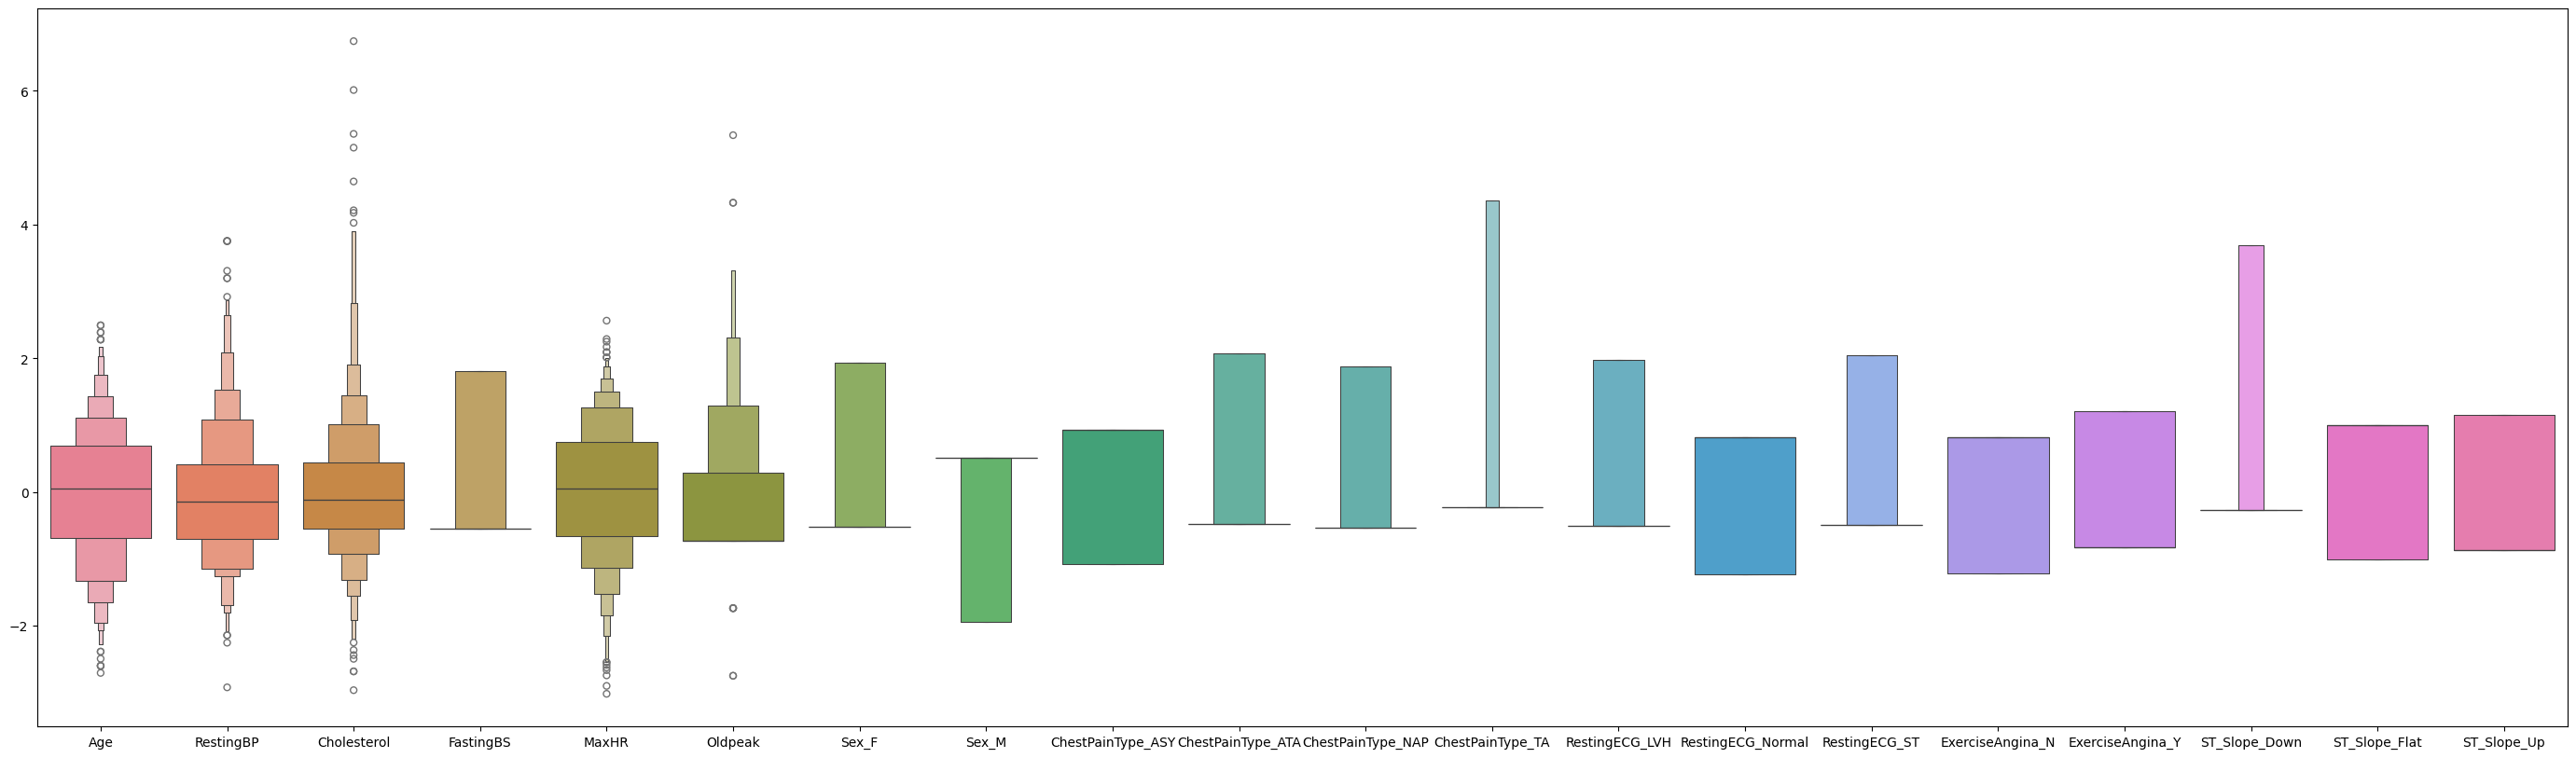

In [22]:
# Visualizing the scaled features
plt.figure(figsize = (35,10))
sns.boxenplot(data = X_scaled)
plt.show()

- Observations:
    Cholesterol and Oldpeak have many outliers that indicate the significant number of extreme patients. 

### Split the Data

In [23]:
# Splitting the data into Training (70%) and Testing (30%) sets
# random_state = 42: ensures split is identical every time the code is run
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.3, random_state = 42)

## Model Building

### 1. Support Vector Machine (SVM)

In [24]:
model1 = svm.SVC()
# Training the SVM on the training data
model1.fit(X_train, y_train)
# Making predictions on the unseen test set
y_pred = model1.predict(X_test)

In [25]:
y_pred

array([0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0])

In [26]:
y_test

668    0
30     1
377    1
535    1
807    0
      ..
133    1
813    0
734    1
360    1
875    0
Name: HeartDisease, Length: 276, dtype: int64

In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.87      0.84       112
           1       0.90      0.86      0.88       164

    accuracy                           0.86       276
   macro avg       0.86      0.86      0.86       276
weighted avg       0.87      0.86      0.86       276



Observations:
- Overall accuracy (86%): SVM correctly predicted the outcome for 85% of the test set.
- Precision (0.90 for Class 1): When the model predicts a patient has heart disease, it is correct 90% of the time.
- Recall (0.86 for Class 1): The model successfully identified 86% of all actual heart disease cases.

### 2. Artificial Neural Network (ANN)

In [28]:
# EarlyStopping: Prevents overfitting by stopping training 
# patience = 20: Wait 20 epochs for improvement before quitting
early_stopping = callbacks.EarlyStopping(
    min_delta = 0.001, patience = 20, restore_best_weights = True)
model = Sequential()
# Input layer: Matches the features from the training dataset
model.add(Dense(units = 16, kernel_initializer = 'uniform', activation = 'relu', input_dim = X_train.shape[1]))
model.add(Dense(units = 8, kernel_initializer = 'uniform', activation = 'relu'))
model.add(Dropout(0.25))
model.add(Dense(units = 8, kernel_initializer = 'uniform', activation = 'relu'))
model.add(Dropout(0.5))
# Output layer
model.add(Dense(units = 1, kernel_initializer = 'uniform', activation = 'sigmoid'))
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │             336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 8)                   │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 553 (2.16 KB)

 Trainable params: 553 (2.16 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Training process of the model
history = model.fit(X_train, y_train, batch_size = 32, epochs = 100, callbacks = [early_stopping], validation_split = 0.2)

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5361 - loss: 0.6931 - val_accuracy: 0.5039 - val_loss: 0.6931
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5439 - loss: 0.6929 - val_accuracy: 0.5039 - val_loss: 0.6931
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5439 - loss: 0.6926 - val_accuracy: 0.5039 - val_loss: 0.6928
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5439 - loss: 0.6917 - val_accuracy: 0.5039 - val_loss: 0.6916
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6121 - loss: 0.6886 - val_accuracy: 0.6512 - val_loss: 0.6872
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7232 - loss: 0.6802 - val_accuracy: 0.8140 - val_loss: 0.6749
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8051 - loss: 0.6603 - val_accuracy: 0.8062 - val_loss: 0.6452
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8304 - loss: 0.6213 - val_accuracy: 0.8140 - 

#### Visualising Losses and Accuracy in Training and Validation

In [30]:
history_df = pd.DataFrame(history.history)

##### Plotting the Training and Validation Losses

[]

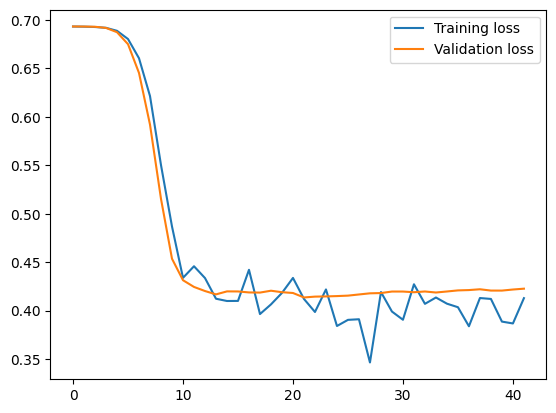

In [31]:
# Training loss: How well the model is learning the training data
plt.plot(history_df.loc[:,['loss']], label = "Training loss")
# Validation loss: How well the model performs on the data it hasn't seen during training
plt.plot(history_df.loc[:,['val_loss']], label = "Validation loss")
plt.legend()
plt.plot()

Observations: 
- Both training and validation loss drop sharply within the first 10 epochs.
- The loss curve shows stable training. The model avoids overfitting as the validation loss doesn't go upward in the end.
- EarlyStopping callback succesfully stopped training at epoch 67. 

##### Plotting the Training and Validation Accuracy

[]

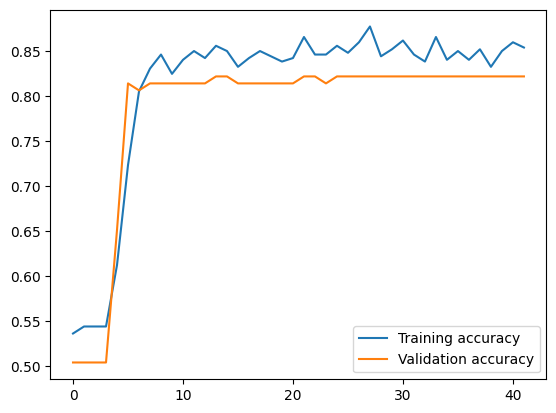

In [32]:
# Training accuracy: Percentage of correct predictions on the training dataset
plt.plot(history_df.loc[:,['accuracy']], label = "Training accuracy")
# Validation accuracy: Percentage of correct predictions on the testing dataset
plt.plot(history_df.loc[:,['val_accuracy']], label = "Validation accuracy")
plt.legend()
plt.plot()

Observations: 
- Model quickly learned in the first 10 epochs where the accuracy jumped from ~55% to ~80%.
- The final validation accuracy is around 86%.

In [33]:
y_pred = model.predict(X_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [34]:
y_pred = (y_pred > 0.5)
print(classification_report(y_test, y_pred))
# 0: Healthy patients, 1: Heart disease patients

              precision    recall  f1-score   support

           0       0.80      0.88      0.83       112
           1       0.91      0.85      0.88       164

    accuracy                           0.86       276
   macro avg       0.85      0.86      0.86       276
weighted avg       0.86      0.86      0.86       276



Observations:
- Overall accuracy (86%): The model correctly made predictions in 86% of the test set.
- Precision (0.91 for Class 1): When the model predicts a patient has heart disease, it is correct 91% of the time.
- Recall (0.85 for Class 1): The model successfully identified 85% of all the actual heart disease cases.

### Observations of the SVM and ANN models:
- The overall accuracy of both the models is same (86%).
- The ANN model gives better precision (91%).
- Recall of SVM is better (86%).

The accuracy averages at 86%, precision at 90-91% and recall at 85-86%. 